In [1]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [2]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns
import shap

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, LabelEncoder
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, ConfusionMatrixDisplay

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [3]:
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True

pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# # plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
# plt.rcParams.update({
#     "figure.facecolor": '#0f0f1a', # Outer panel (figure)
#     "axes.facecolor":   '#1a1a2e', # Inner panel (image)
#     "axes.edgecolor":   '#444466',
#     "axes.labelcolor":  '#e0e0ff',
#     "text.color":       'lightblue',
#     "xtick.color":      '#e0e0ff',
#     "ytick.color":      '#e0e0ff',
#     "grid.color":       '#2a2a4a',
#     "grid.alpha":       0.5,
#     "font.family":      'monospace',
# })

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)

## -- Set Global Configuration --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RED': '\033[31m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']}")
print(f"{CFG['YELLOW']}YELLOW {CFG['RESET']} {CFG['RED']} RED {CFG['RESET']}")

CLASSIC  GREEN 
YELLOW   RED 


In [4]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e6/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
    test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

    ORIG_PATH = "/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/"
    orig = pd.read_csv(ORIG_PATH+'star_classification.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == "colab":
    from google.colab import drive
    drive.mount("/content/drive")

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e6 | Stellar Class/_stellar_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv").drop('id', axis=1)
    test = pd.read_csv(PATH+"test.csv").drop('id', axis=1)
    orig = pd.read_csv(PATH+"star_classification.csv")#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]
CATS   = ["spectral_type", "galaxy_population"]

NUMS   = [c for c in train.columns if c not in CATS+[TARGET, 'id']]
BASE   = NUMS + CATS

mapping   = {c: i for i, c in enumerate(train[TARGET].unique())}
r_mapping = {i: c for i, c in enumerate(train[TARGET].unique())}

# for df in [train, orig]:
#     df[TARGET] = df[TARGET].map(mapping)

for (name, df) in [("Train", train), ("Test", test), ("Original", orig)]:
    print(f"{name} shape: {df.shape}")

print(f"\nTotal nums: {len(NUMS)}")
print(f"Total cats: {len(CATS)}")
print(f"Total base: {len(BASE)}")

Train shape: (577347, 11)
Test shape: (247435, 10)
Original shape: (100000, 18)

Total nums: 8
Total cats: 2
Total base: 10


In [5]:
## -- ['spectral_type', 'galaxy_population'] derivation for original data --
def spectral_type(g, r):
    return pd.cut(
        r-g, 
        [-np.inf, -1, -0.5, 0, np.inf],
        labels=['M', 'G/K', 'A/F', 'O/B']
    ).astype(str)

def galaxy_population(u, r):
    return pd.cut(
        u-r, 
        [-np.inf, 2.2, np.inf],
        labels=['Blue_Cloud', 'Red_Sequence']
    ).astype(str)

orig['spectral_type'] = spectral_type(orig['g'], orig['r'])
orig['galaxy_population'] = galaxy_population(orig['u'], orig['r'])

orig.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,spectral_type,galaxy_population
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171,M,Red_Sequence
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427,A/F,Blue_Cloud
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299,M,Red_Sequence
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775,M,Blue_Cloud
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842,M,Red_Sequence


In [6]:
display(train.head())
train.info()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  object 
 9   galaxy_population  577347 non-null  object 
 10  class              577347 non-null  object 
dtypes: float64(8), object(3)
memory usage: 48.5+ MB


In [7]:
train[NUMS].describe()

,alpha,delta,u,g,r,i,z,redshift
count,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


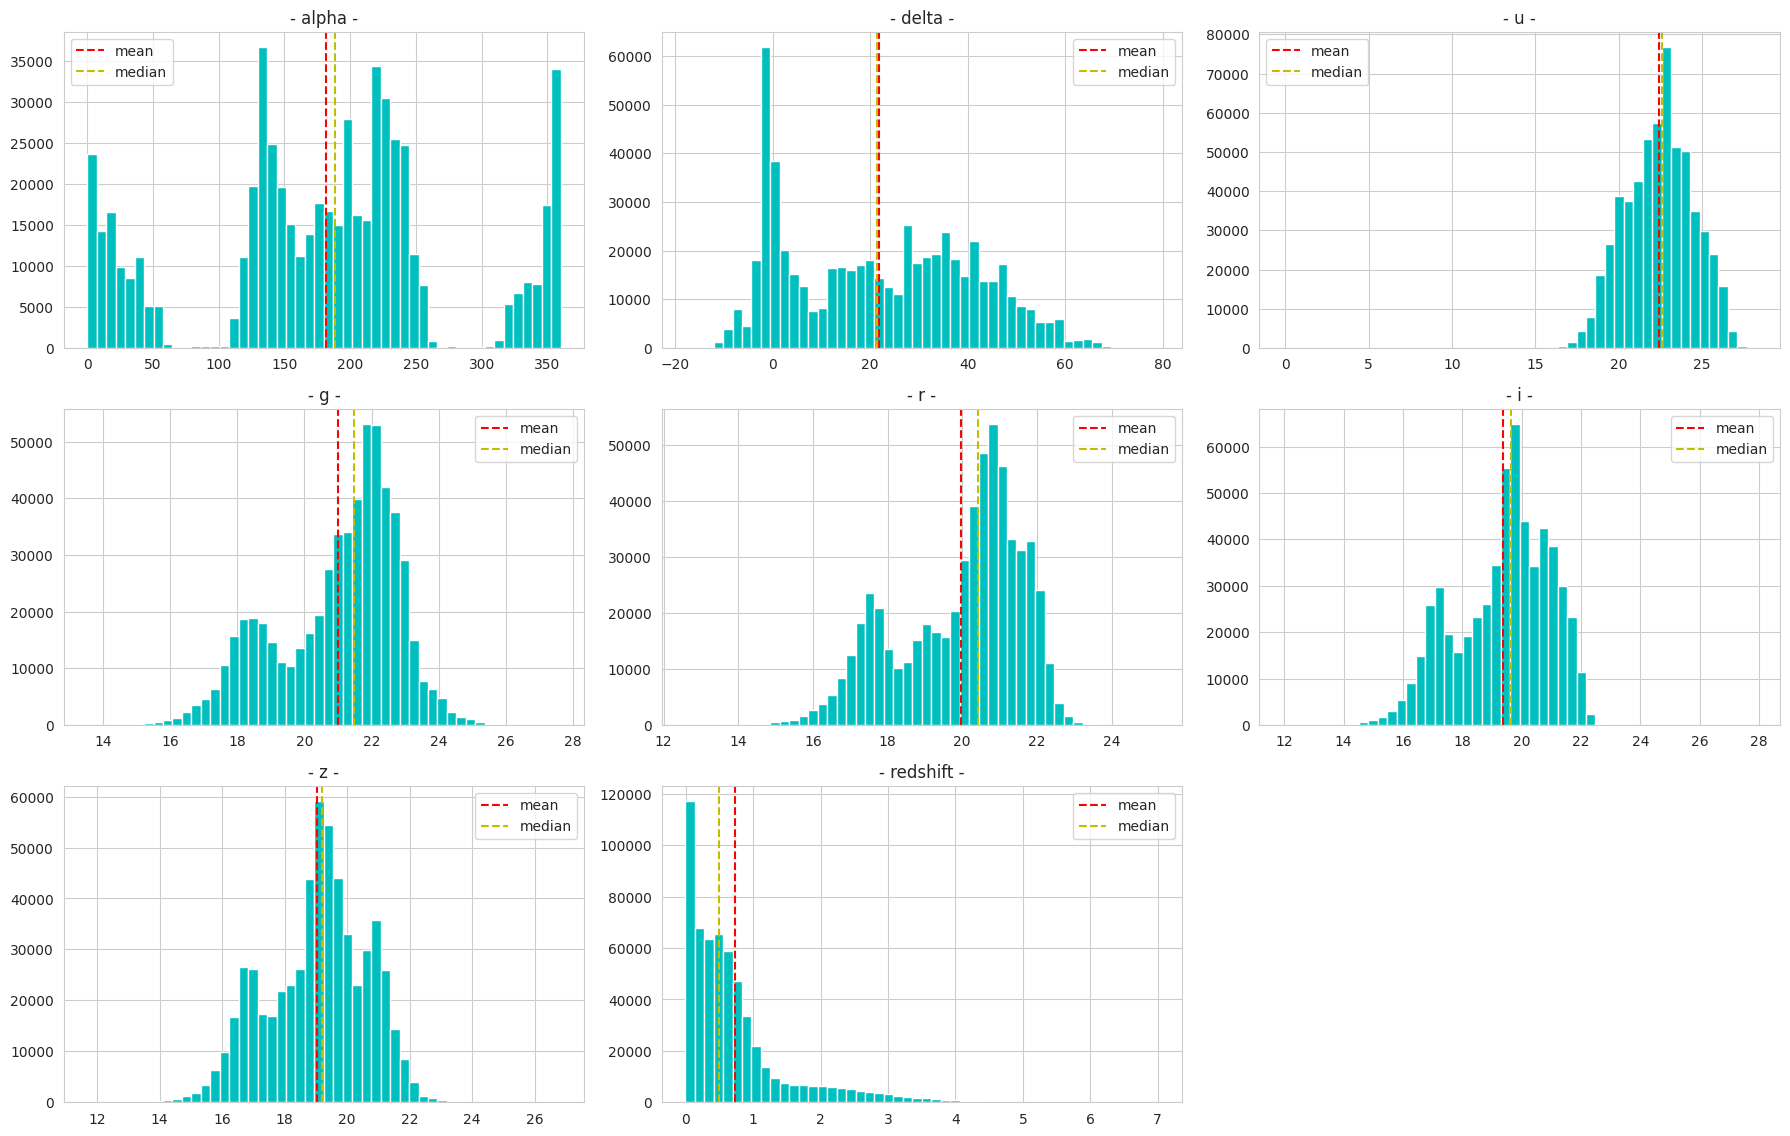

In [8]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
Train,439819,444062,577347,577347,577347,577347,577347,573975,4,2
Original,99999,99999,93748,92651,91901,92019,92007,99295,4,2
Test,200893,201819,247435,247435,247435,247435,247435,246031,4,2


In [10]:
n_unique = train[BASE].nunique().sort_values()
n_unique

galaxy_population         2
spectral_type             4
alpha                439819
delta                444062
redshift             573975
r                    577347
g                    577347
u                    577347
z                    577347
i                    577347
dtype: int64

In [11]:
def get_class_weights(y):
    """
    y: Current y labels -> numpy array or series
    """
    cls_ = np.unique(y)
    wts_ = compute_class_weight("balanced", classes=cls_, y=y)
    return dict(zip(cls_, wts_))

def get_sample_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return np.array([opt[label] for label in y])
    else:
        cls_ = np.unique(y_true)
        wts_ = compute_class_weight('balanced', classes=cls_, y=y_true)
        cls_wts = dict(zip(cls_, wts_))
        return np.array([cls_wts[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def multi_class_brier(y_true, y_proba, classes):
    y_onehot = label_binarize(y_true, classes=classes)
    return float(np.mean(np.sum((y_onehot - y_proba) ** 2, axis=1)))

def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED']).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

print('- Helper functions ready -')

- Helper functions ready -


## FEATURE ENGINEERING

In [12]:
## -- Digit extractions & binning --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [13]:
# for col in ['redshift']:
#     # print(f"\nRounding... ", end='')
#     # for r in range(-3, 6):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     # print(f"\nDigitizing... ", end='')
#     # for d in range(1):
#     #     d_n = f'{col}_{d}_digit_'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nEqual binning... ", end='')
#     # for b in [32, 64, 128]: # 100, 500, 1000
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     print(f"\nQuantile binning... ", end='')
#     for q in [4]:
#         q_n = f'{col}_Qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [14]:
# for col in ["delta", "alpha", "redshift"]:
#     print(f"\nRounding... ", end='')
#     for r in range(-3, 5):
#         r_n = f"{col}_round_{r}"
#         print(r_n+', ', end='')
#         train[r_n] = train[col].round(r).astype('int32')
#         test[r_n]  = test[col].round(r).astype('int32')
#         orig[r_n]  = orig[col].round(r).astype('int32')
#         ## -- Drop irrelevant features --
#         if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#             DROP_COLS.append(r_n)
#         else:
#             ROUNDS.append(r_n)
    
#     # print(f"\nExtracting digits... ", end='')
#     # for d in range(-3, 6):
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nEqual binning... ", end='')
#     # for b in [100]: # 50, 100, 400
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     # Fit on train data and transform both train and test
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)
        
#     # print(f"\nQuantile binning... ", end='')
#     # for q in [100, 500]: 
#     #     q_n = f'{col}_qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [15]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [16]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Series([], dtype: float64)

In [17]:
# plt.figure(figsize=(18, 5))
# ax = (train.groupby(by=Q_BINS[0])[TARGET].mean() / 3).plot(linestyle='-.', label=Q_BINS[0])
# (train.groupby(by=Q_BINS[2])[TARGET].mean() / 3).plot(linestyle='-.', ax=ax, label=Q_BINS[2])

# plt.legend()
# plt.show()

In [18]:
# def add_frequency_condition(df1, cols, thresh=5): 
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [19]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
#     n_col = f"_Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(top_cols, 3)), desc='Triplewise'):
# #     n_col = f"_Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(top_cols, low_cols)), desc='One-to-Many'):
# #     n_col = f"_Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")

In [20]:
## -- Arithmetic interaction --
for df in tqdm([train, test, orig]):
    df['_sub_u_g'] = df['u'] - df['g']
    df['_sub_g_r'] = df['g'] - df['r']
    df['_sub_g_i'] = df['g'] - df['i']
    df['_sub_r_z'] = df['r'] - df['z']
    df['_sub_i_z'] = df['i'] - df['z']
    df['_sub_r_i'] = df['r'] - df['i']

    df["_stellar_locus_dist"] = np.sqrt((df['_sub_g_r'] - 0.52)**2 + (df['_sub_r_i'] - 0.25)**2)

    for band in ['g', 'i']:
        b_col = f"_div_{band}_redshift"
        df[b_col] = df[band] / (df['redshift'] + 1e-6)

color_bands = [c for c in train.columns if c.startswith('_sub_') or c.startswith('_div_')]
color_bands.append("_stellar_locus_dist")

train[color_bands].describe()

  0%|          | 0/3 [00:00<?, ?it/s]

,_sub_u_g,_sub_g_r,_sub_g_i,_sub_r_z,_sub_i_z,_sub_r_i,_div_g_redshift,_div_i_redshift,_stellar_locus_dist
count,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,5.773470e+05,5.773470e+05,577347.000000
mean,1.434652,1.044463,1.628362,0.921675,0.337775,0.583900,9.081604e+02,8.735087e+02,0.940107
std,1.142003,0.736291,1.073617,0.675999,0.395797,0.496787,2.578451e+05,2.542172e+05,0.540065
min,-23.155858,-8.104372,-10.807923,-14.008533,-14.210769,-10.757964,-1.719873e+08,-1.713189e+08,0.001131
25%,0.598523,0.419982,0.634816,0.412939,0.094029,0.215544,2.422425e+01,2.196961e+01,0.478341
50%,1.333334,1.075605,1.681938,0.913850,0.343779,0.570048,4.149269e+01,3.716272e+01,0.878239
75%,2.087557,1.646067,2.551026,1.412064,0.590450,0.946885,9.989013e+01,9.107308e+01,1.367064
max,7.523080,8.874428,9.284916,9.492911,7.624849,8.749329,3.962015e+07,3.559959e+07,12.108608


In [21]:
## -- Cyclic encoding --
for df in [train, test, orig]:
    for col in ['alpha']:
        for p in [180, 360]:
            df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
            df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

for df in [train, test, orig]:
    for col in ['delta']:
        for p in [180]:
            df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
            df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

cyclic_cols = [c for c in train.columns if c.endswith('_sin_') or c.endswith('_cos_')]

train[cyclic_cols].head()

,alpha_180_sin_,alpha_180_cos_,alpha_360_sin_,alpha_360_cos_,delta_180_sin_,delta_180_cos_
0,-0.902822,0.430015,0.533847,-0.845581,0.558014,0.829832
1,-0.970200,-0.242305,0.788132,-0.615506,0.904034,0.427461
2,-0.007238,0.999974,0.003619,-0.999993,0.943741,0.330684
3,0.999592,-0.028560,-0.717133,-0.696936,0.992248,-0.124274
4,-0.971664,0.236368,0.617913,-0.786247,0.625048,0.780586


In [22]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreating frequencies... ", end='')
# for col in CATS:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print(f"\n✓ Total frequency features: {len(freq_cols)}")

In [23]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
#     n_col = f"_Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_COLS, 3)), desc='Triplewise'):
# #     n_col = f"_Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(TOP_COLS, LOW_COLS)), desc='One-to-Many'):
# #     n_col = f"_Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total interaction features: {len(INTER)}")

# train[INTER].head()

In [24]:
# from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

# class TargetEncoder(BaseEstimator, TransformerMixin):
#     """
#     Target Encoder that supports multiple aggregation functions,
#     internal cross-validation for leakage prevention, and smoothing.

#     Parameters
#     ----------
#     cols_to_encode : list of str
#         List of column names to be target encoded.

#     aggs : list of str, default=['mean']
#         List of aggregation functions to apply. Any function accepted by
#         pandas' `.agg()` method is supported, such as:
#         'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
#         'count', 'sum', 'median'.
#         Smoothing is applied only to the 'mean' aggregation.

#     cv : int, default=5
#         Number of folds for cross-validation in fit_transform.

#     smooth : float or 'auto', default='auto'
#         The smoothing parameter `m`. A larger value puts more weight on the 
#         global mean. If 'auto', an empirical Bayes estimate is used.
        
#     drop_original : bool, default=False
#         If True, the original columns to be encoded are dropped.
#     """
#     def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
#         self.cols_to_encode = cols_to_encode
#         self.aggs = aggs
#         self.cv = cv
#         self.smooth = smooth
#         self.drop_original = drop_original
#         self.mappings_ = {}
#         self.global_stats_ = {}

#     def fit(self, X, y):
#         """
#         Learn mappings from the entire dataset.
#         These mappings are used for the transform method on validation/test data.
#         """
#         temp_df = X.copy()
#         temp_df['target'] = y

#         # Learn global statistics for each aggregation
#         for agg_func in self.aggs:
#             self.global_stats_[agg_func] = y.agg(agg_func)

#         # Learn category-specific mappings
#         for col in self.cols_to_encode:
#             self.mappings_[col] = {}
#             for agg_func in self.aggs:
#                 mapping = temp_df.groupby(col)['target'].agg(agg_func)
#                 self.mappings_[col][agg_func] = mapping
        
#         return self

#     def transform(self, X):
#         """
#         Apply learned mappings to the data.
#         Unseen categories are filled with global statistics.
#         """
#         X_transformed = X.copy()
#         for col in self.cols_to_encode:
#             for agg_func in self.aggs:
#                 new_col_name = f'TE_{col}_{agg_func}'
#                 map_series = self.mappings_[col][agg_func]
#                 X_transformed[new_col_name] = X[col].map(map_series)
#                 X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
#         return X_transformed

#     def fit_transform(self, X, y):
#         """
#         Fit and transform the data using internal cross-validation to prevent leakage.
#         """
#         # First, fit on the entire dataset to get global mappings for transform method
#         self.fit(X, y)

#         # Initialize an empty DataFrame to store encoded features
#         encoded_features = pd.DataFrame(index=X.index)
        
#         kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

#         for train_idx, val_idx in kf.split(X, y):
#             X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#             X_val = X.iloc[val_idx]
            
#             temp_df_train = X_train.copy()
#             temp_df_train['target'] = y_train

#             for col in self.cols_to_encode:
#                 # --- Calculate mappings only on the training part of the fold ---
#                 for agg_func in self.aggs:
#                     new_col_name = f'TE_{col}_{agg_func}'
                    
#                     # Calculate global stat for this fold
#                     fold_global_stat = y_train.agg(agg_func)
                    
#                     # Calculate category stats for this fold
#                     mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

#                     # --- Apply smoothing only for 'mean' aggregation ---
#                     if agg_func == 'mean':
#                         counts = temp_df_train.groupby(col)['target'].count()
                        
#                         m = self.smooth
#                         if self.smooth == 'auto':
#                             # Empirical Bayes smoothing
#                             variance_between = mapping.var()
#                             avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
#                             if variance_between > 0:
#                                 m = avg_variance_within / variance_between
#                             else:
#                                 m = 0  # No smoothing if no variance between groups
                        
#                         # Apply smoothing formula
#                         smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
#                         encoded_values = X_val[col].map(smoothed_mapping)
#                     else:
#                         encoded_values = X_val[col].map(mapping)
                    
#                     # Store encoded values for the validation fold
#                     encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

#         # Merge with original DataFrame
#         X_transformed = X.copy()
#         for col in encoded_features.columns:
#             X_transformed[col] = encoded_features[col]
            
#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
#         return X_transformed


# class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
#     def __init__(self, cat_cols=None):
#         self.cat_cols = cat_cols
#         self.mappings_ = {}
#     def fit(self, X, y):
#         X = X.copy()
#         if self.cat_cols is None:
#             self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
#         self.mappings_ = {}
#         for col in self.cat_cols:
#             df_temp = pd.DataFrame({col: X[col], 'y': y})
#             group_means = df_temp.groupby(col, dropna=False)['y'].mean()
#             sorted_categories = group_means.sort_values().index
#             self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
#         return self

#     def transform(self, X, y=None):
#         X = X.copy()
#         for col, mapping in self.mappings_.items():
#             if col in X.columns:
#                 X[col] = X[col].map(mapping)
#         return X

In [25]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_valid: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_valid.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_valid.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_valid.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [26]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE+DIGITS, #+DIGITS, #+ROUNDS,
#     target=TARGET,
#     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

In [27]:
# ## -- Duplicate all numerics as categories --
# CATS_2    = []
# _num_cats = ['Cumulative_Degradation', 'LapTime (s)', 'LapTime_Delta']

# for c in _num_cats:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- FACTORIZE CATS_2 --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     v = combine.factorize()[0]
#     train[n] = v[:len(train)].astype('int32')
#     test[n]  = v[len(train):len(train)+len(test)].astype('int32')
#     orig[n]  = v[len(train)+len(test):].astype('int32')

# print(f'Nums to Cats: {len(CATS_2)}')

In [28]:
## -- Factorize using combined data --
for c in CATS: # +INTER
    combined = pd.concat([train[c], test[c], orig[c]])
    # combined = combined.factorize()[0]
    combined = pd.Series(combined).astype(str).astype("category")
    train[c] = combined[:len(train)]
    test[c]  = combined[len(train):len(train)+len(test)]
    orig[c]  = combined[len(train)+len(test):]

print('Label encoding complete!')

Label encoding complete!


In [29]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head() 

Total Features: 25


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class,_sub_u_g,_sub_g_r,_sub_g_i,_sub_r_z,_sub_i_z,_sub_r_i,_stellar_locus_dist,_div_g_redshift,_div_i_redshift,alpha_180_sin_,alpha_180_cos_,alpha_360_sin_,alpha_360_cos_,delta_180_sin_,delta_180_cos_
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY,3.576564,1.537632,2.638446,1.736869,0.636056,1.100813,1.326446,53.536563,47.085332,-0.902822,0.430015,0.533847,-0.845581,0.558014,0.829832
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY,1.691447,1.499854,1.860995,0.800775,0.439634,0.361141,0.986137,120.821925,109.041746,-0.970200,-0.242305,0.788132,-0.615506,0.904034,0.427461
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO,-0.043925,-0.092712,0.496499,0.614474,0.025263,0.589211,0.700343,7.464886,7.289058,-0.007238,0.999974,0.003619,-0.999993,0.943741,0.330684
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY,2.254320,2.032982,2.685077,1.102802,0.450706,0.652096,1.565502,39.266460,34.257919,0.999592,-0.028560,-0.717133,-0.696936,0.992248,-0.124274
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY,2.231478,1.237231,1.572233,0.618264,0.283262,0.335002,0.722251,35.035981,32.207015,-0.971664,0.236368,0.617913,-0.786247,0.625048,0.780586


## Prepare data for H20

In [30]:
try:
    import h2o
except:
    %pip install -q -U h2o
    import h2o
    
from h2o import H2OFrame
from h2o.automl import H2OAutoML

print('h2o version:', h2o.__version__)

h2o version: 3.46.0.11


In [31]:
# ## -- Trainer for h2o.H20Frame
# def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, cat_cols):
#     print(f"\n===== Starting CV: {model_name} =====")
#     start = time()

#     y = train_df[target]
#     num_cls = y.nunique()

#     oof_preds = np.zeros((len(train_df), num_cls))
#     test_preds = np.zeros((len(test_df), num_cls))
#     fold_scores = []

#     oof_glm = np.zeros((len(train_df), num_cls))
#     oof_gbm = np.zeros((len(train_df), num_cls))
#     oof_drf = np.zeros((len(train_df), num_cls))
#     oof_xgb = np.zeros((len(train_df), num_cls))
#     oof_dpl = np.zeros((len(train_df), num_cls))

#     test_glm = np.zeros((len(test_df), num_cls))
#     test_gbm = np.zeros((len(test_df), num_cls))
#     test_drf = np.zeros((len(test_df), num_cls))
#     test_xgb = np.zeros((len(test_df), num_cls))
#     test_dpl = np.zeros((len(test_df), num_cls))

#     h2o_models = [
#         ("glm", oof_glm, test_glm),
#         ("gbm", oof_gbm, test_gbm),
#         ("drf", oof_drf, test_drf),
#         ("xgboost", oof_xgb, test_xgb),
#         ("deeplearning", oof_dpl, test_dpl),
#     ]
#     ## ---------------------------------------------------------------------------------
#     h2o.init(verbose=True, nthreads=os.cpu_count(), max_mem_size="20G")
    
#     test_df[TARGET] = "Null"
#     df_ = pd.concat([train_df, test_df])
#     h2o_df = H2OFrame(df_)

#     ## -- Split train set --
#     h2o_train = h2o_df[h2o_df[TARGET] != "Null"]
#     h2o_train[TARGET] = h2o_train[TARGET].asfactor()

#     ## -- Split test set --
#     h2o_test = h2o_df[h2o_df[TARGET] == "Null"]
#     # h2o_test = h2o_test.drop([TARGET])

#     for col in cat_cols:
#         h2o_train[col] = h2o_train[col].asfactor()
#         h2o_test[col]  = h2o_test[col].asfactor()
#     ## ---------------------------------------------------------------------------------

#     n_splits = kf.n_splits

#     for idx, (train_idx, val_idx) in enumerate(kf.split(train_df[features], y)):
#         print(f"\n{CFG["YELLOW"]}##### FOLD {idx+1}/{n_splits} | ", end="")

#         train_idx = list(train_idx.ravel())
#         val_idx = list(val_idx.ravel())

#         X_train = h2o_train[[int(i) for i in train_idx], :]
#         X_valid = h2o_train[[int(i) for i in val_idx], :]
#         X_test  = h2o_test[:, features]

#         print(f"Train shape: {X_train.shape}{CFG["RESET"]}")

#         ## --------------------------------------------------------------------------------------
#         model = H2OAutoML(**params)
#         model.train(features, target, training_frame=X_train, validation_frame=X_valid)
#         ## --------------------------------------------------------------------------------------
#         ## -- LEADER MODEL -- 
#         oof_preds_ = model.leader.predict(X_valid).as_data_frame(use_multi_thread=True)
#         oof_preds[val_idx] = oof_preds_.iloc[:, -num_cls:].to_numpy()

#         test_preds_ = model.leader.predict(X_test).as_data_frame(use_multi_thread=True)
#         test_preds += test_preds_.iloc[:, -num_cls:].to_numpy()
#         ## --------------------------------------------------------------------------------------
#         ## -- PER MODEL BASELINE -- 
#         for (mod, x_oof, x_tst) in h2o_models:
#             print(f" ••• Predicting with {mod}")
#             algo_model = model.get_best_model(algorithm=mod)

#             if algo_model is not None:
#                 single_oof = algo_model.predict(X_valid).as_data_frame(use_multi_thread=True)
#                 x_oof[val_idx] = single_oof.iloc[:, -num_cls:].to_numpy()

#                 single_test = algo_model.predict(X_test).as_data_frame(use_multi_thread=True)
#                 x_tst += single_test.iloc[:, -num_cls:].to_numpy()
#             else:
#                 print(f"    ⚠️ Warning: No model found for {mod} in this fold.")
#         ## ---------------------------------------------------------------------------------------

#         ## -- Get fold score --
#         # Use target mapping cleanly onto validation series
#         fold_score = balanced_acc(y[val_idx].map(mapping), oof_preds[val_idx])
#         fold_scores.append(fold_score)
#         print(f"{CFG["YELLOW"]} • Fold_{idx+1} bal_acc: {fold_score:.5f}{CFG["RESET"]}")

#     ## -- Average the test predictions outside the main fold loop
#     test_preds /= n_splits

#     ## -- FIX 3: Fixed variable unpacking for clean output messages
#     for (mod, __, x_tst) in tqdm(h2o_models, desc="Averaging model tests"):
#         print(f"• {mod}... ", end="")
#         x_tst /= n_splits

#     ## -- Print CV results
#     print("\n==================================================")
#     print(f"{n_splits}-FOLDS CV: {model_name}")
#     print("==================================================")
#     for i, score in enumerate(fold_scores):
#         print(f" • Fold {i+1} score: {score:.5f}")
    
#     ## -- Final out-of-fold --
#     overall_score = np.round(balanced_acc(y.map(mapping), oof_preds), 5)
#     print("-------------------------------------------------|")
#     print(f"OOF score: {overall_score}")
#     print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f'{((time() - start) / 60):.2f} mins')

#     return {
#         "oof_preds": oof_preds,
#         "test_preds": test_preds,
#         "h2o": h2o_models,
#         "score": overall_score,
#         "model": model,
#         "val_data": X_valid, 
#     }

# print("⚙️ Trainer function ready ⚙️")

In [32]:
## -- Trainer for pandas DataFrame
def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, cat_cols):
    print(f"\n===== Starting CV: {model_name} =====")
    start = time()

    ## - Initialize H2O once -- 
    h2o.init(verbose=False, nthreads=os.cpu_count(), max_mem_size="20G") 

    X = train_df[features]
    y = train_df[target]

    num_cls = y.nunique()

    oof_glm = np.zeros((len(X), num_cls))
    oof_gbm = np.zeros((len(X), num_cls))
    oof_drf = np.zeros((len(X), num_cls))
    oof_xgb = np.zeros((len(X), num_cls))
    oof_dpl = np.zeros((len(X), num_cls))

    test_glm = np.zeros((len(test_df), num_cls))
    test_gbm = np.zeros((len(test_df), num_cls))
    test_drf = np.zeros((len(test_df), num_cls))
    test_xgb = np.zeros((len(test_df), num_cls))
    test_dpl = np.zeros((len(test_df), num_cls))

    h2o_models = [
        ("glm", oof_glm, test_glm),
        ("gbm", oof_gbm, test_gbm),
        ("drf", oof_drf, test_drf),
        ("xgboost", oof_xgb, test_xgb),
        ("deeplearning", oof_dpl, test_dpl),
    ]

    oof_preds  = np.zeros((len(X), num_cls))
    test_preds = np.zeros((len(test_df), num_cls))
    fold_scores = []
        
    n_splits = kf.n_splits

    for idx, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"\n{CFG["YELLOW"]}##### FOLD {idx+1}/{n_splits} | ", end="")
        
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        print(f"Train shape: {X_train.shape}{CFG["RESET"]}")

        # Prepare frames
        h2o_X_frame = H2OFrame(pd.concat([X_train, y_train], axis=1))
        h2o_V_frame = H2OFrame(pd.concat([X_valid, y_valid], axis=1))
        h2o_valid   = H2OFrame(X_valid)
        h2o_test    = H2OFrame(X_test)

        # Recognize target as a factor column
        h2o_X_frame[target] = h2o_X_frame[target].asfactor()
        h2o_V_frame[target] = h2o_V_frame[target].asfactor()
    
        for col in cat_cols:
            h2o_X_frame[col] = h2o_X_frame[col].asfactor()
            h2o_V_frame[col] = h2o_V_frame[col].asfactor()
            h2o_valid[col]   = h2o_valid[col].asfactor()
            h2o_test[col]    = h2o_test[col].asfactor()

        ## --------------------------------------------------------------------------------------
        model = H2OAutoML(**params)
        model.train(
            y=target,
            training_frame=h2o_X_frame,
            # validation_frame=h2o_V_frame,
        )
        ## --------------------------------------------------------------------------------------

        ## -- LEADER MODEL -- 
        oof_preds_ = model.leader.predict(h2o_valid).as_data_frame(use_multi_thread=True)
        oof_preds[val_idx] = oof_preds_.iloc[:, -num_cls:].to_numpy()

        test_preds_ = model.leader.predict(h2o_test).as_data_frame(use_multi_thread=True)
        test_preds += test_preds_.iloc[:, -num_cls:].to_numpy()

        ## --------------------------------------------------------------------------------------
        ## -- PER MODEL BASELINE -- 
        for (mod, x_oof, x_tst) in h2o_models:
            print(f" ••• Predicting with {mod}")
            algo_model = model.get_best_model(algorithm=mod)
            
            if algo_model is not None:
                single_oof = algo_model.predict(h2o_valid).as_data_frame(use_multi_thread=True)
                x_oof[val_idx] = single_oof.iloc[:, -num_cls:].to_numpy()

                single_test = algo_model.predict(h2o_test).as_data_frame(use_multi_thread=True)
                x_tst += single_test.iloc[:, -num_cls:].to_numpy()
            else:
                print(f"   ⚠️ Warning: No model found for {mod} in this fold.")
        ## ---------------------------------------------------------------------------------------
        
        ## -- Get fold score --
        # Use target mapping cleanly onto validation series
        fold_score = balanced_acc(y_valid.map(mapping), oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"{CFG["YELLOW"]} • Fold_{idx+1} bal_acc: {fold_score:.5f}{CFG["RESET"]}")

    ## -- Average the test predictions outside the main fold loop
    test_preds /= n_splits

    # FIX 3: Fixed variable unpacking for clean output messages
    for (mod, __, x_tst) in tqdm(h2o_models, desc="Averaging model tests"):
        print(f"• {mod}... ", end="")
        x_tst /= n_splits

    ## -- Print CV results
    print("\n==================================================")
    print(f"{n_splits}-FOLDS CV: {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores):
        print(f" • Fold {i+1} score: {score:.5f}")
    
    ## -- Final out-of-fold --
    overall_score = np.round(balanced_acc(y.map(mapping), oof_preds), 5)
    print("-------------------------------------------------|")
    print(f"OOF score: {overall_score}")
    print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins')

    return {
        "oof_preds": oof_preds,
        "test_preds": test_preds,
        "h2o": h2o_models,
        "score": overall_score,
        "model": model,
        "val_data": h2o_V_frame, 
    }

In [33]:
all_predictions = {}

MULTI_SEEDS = [CFG["SEED"], 777, 1234, 24611, 0]
ALL_CATS = CATS #+ INTER

CFG["FOLDS"] = 8
skf = StratifiedKFold(n_splits=CFG["FOLDS"], shuffle=True, random_state=CFG["SEED"])

USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, stratify=train[TARGET], train_size=50_000, random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class,_sub_u_g,_sub_g_r,_sub_g_i,_sub_r_z,_sub_i_z,_sub_r_i,_stellar_locus_dist,_div_g_redshift,_div_i_redshift,alpha_180_sin_,alpha_180_cos_,alpha_360_sin_,alpha_360_cos_,delta_180_sin_,delta_180_cos_
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY,3.576564,1.537632,2.638446,1.736869,0.636056,1.100813,1.326446,53.536563,47.085332,-0.902822,0.430015,0.533847,-0.845581,0.558014,0.829832
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY,1.691447,1.499854,1.860995,0.800775,0.439634,0.361141,0.986137,120.821925,109.041746,-0.970200,-0.242305,0.788132,-0.615506,0.904034,0.427461
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO,-0.043925,-0.092712,0.496499,0.614474,0.025263,0.589211,0.700343,7.464886,7.289058,-0.007238,0.999974,0.003619,-0.999993,0.943741,0.330684
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY,2.254320,2.032982,2.685077,1.102802,0.450706,0.652096,1.565502,39.266460,34.257919,0.999592,-0.028560,-0.717133,-0.696936,0.992248,-0.124274
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY,2.231478,1.237231,1.572233,0.618264,0.283262,0.335002,0.722251,35.035981,32.207015,-0.971664,0.236368,0.617913,-0.786247,0.625048,0.780586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,M,Red_Sequence,GALAXY,1.974528,1.151093,1.663665,1.151752,0.639180,0.512571,0.683537,36.858784,33.606424,0.998700,0.050966,-0.688852,-0.724902,0.087284,0.996183
577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence,GALAXY,1.375570,1.661308,3.178909,1.750591,0.232989,1.517602,1.705695,33.950042,29.123204,0.999258,0.038528,-0.693351,-0.720600,0.989115,0.147142
577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,M,Red_Sequence,GALAXY,0.728394,2.189890,2.443580,0.822570,0.568879,0.253691,1.669894,56.373667,49.880713,0.968070,-0.250682,0.790785,0.612094,0.023451,0.999725
577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,G/K,Blue_Cloud,QSO,0.347115,0.635191,0.691842,-0.490559,-0.547210,0.056651,0.225062,7.538372,7.297174,0.710499,-0.703699,-0.922957,-0.384904,0.980547,-0.196282


In [34]:
for idx, (t_idx, v_idx) in enumerate(skf.split(train_data[FEATURES], train_data[TARGET])):
    print(f"FOLD {idx+1}/{skf.n_splits} {'-'*25}")
    print(f"  train: {[int(i) for i in t_idx][25:30]}")
    print(f"  valid: {[int(i) for i in v_idx][25:30]}")

FOLD 1/8 -------------------------
  train: [30, 31, 32, 33, 34]
  valid: [206, 212, 216, 235, 236]
FOLD 2/8 -------------------------
  train: [29, 30, 31, 32, 33]
  valid: [200, 210, 215, 220, 225]
FOLD 3/8 -------------------------
  train: [27, 28, 29, 30, 31]
  valid: [199, 204, 218, 226, 227]
FOLD 4/8 -------------------------
  train: [26, 27, 28, 29, 30]
  valid: [208, 211, 219, 222, 239]
FOLD 5/8 -------------------------
  train: [29, 30, 32, 33, 34]
  valid: [243, 250, 256, 271, 275]
FOLD 6/8 -------------------------
  train: [34, 35, 36, 37, 39]
  valid: [164, 167, 179, 191, 201]
FOLD 7/8 -------------------------
  train: [26, 27, 28, 29, 30]
  valid: [223, 234, 247, 248, 264]
FOLD 8/8 -------------------------
  train: [31, 32, 33, 34, 35]
  valid: [186, 189, 190, 197, 202]


In [35]:
# !rm -r /kaggle/working/ 

In [36]:
VERS = "h2o_f3"

if all_predictions:
    all_predictions.clear()

PARAMS = {
    'max_models': 20,
    'max_runtime_secs': 5000,
    # 'max_runtime_secs_per_model': 300,
    'nfolds': 3, # def=-1, 0 if validation_frame is provided
    'stopping_rounds': 5, # 10
    # "balance_classes": True,
    # "stopping_metric": 'AUC',
    # "preprocessing": ['target_encoding'],
    'seed': CFG['SEED'],
}

n = VERS

# for VALUE in [3, 5, 10]: #
#     PARAMS["stopping_rounds"] = VALUE
# n = VERS + str(VALUE)
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=skf,
    cat_cols=ALL_CATS,
)


===== Starting CV: h2o_f3 =====

##### FOLD 1/8 | Train shape: (505178, 25)
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
 ••• Predicting with glm
glm prediction progress: |█████████████████

Averaging model tests:   0%|          | 0/5 [00:00<?, ?it/s]

• glm... • gbm... • drf... • xgboost... • deeplearning... 
8-FOLDS CV: h2o_f3
 • Fold 1 score: 0.95552
 • Fold 2 score: 0.95637
 • Fold 3 score: 0.95779
 • Fold 4 score: 0.95475
 • Fold 5 score: 0.95610
 • Fold 6 score: 0.95700
 • Fold 7 score: 0.95600
 • Fold 8 score: 0.95656
-------------------------------------------------|
OOF score: 0.95626
AVG score: 0.95626 ± 0.00086
-------------------------------------------------|
681.50 mins


In [37]:
# + cyclic, + color_bands
# ==================================================
# 5-FOLDS CV: h2o_fe0
# ==================================================
#  • Fold 1 score: 0.95261
#  • Fold 2 score: 0.95130
#  • Fold 3 score: 0.95230
#  • Fold 4 score: 0.95447
#  • Fold 5 score: 0.95209
# -------------------------------------------------|
# OOF score: 0.95255
# AVG score: 0.95255 ± 0.00105
# -------------------------------------------------|
# 50.84 mins

{'h2o_f3': np.float64(0.95626)}


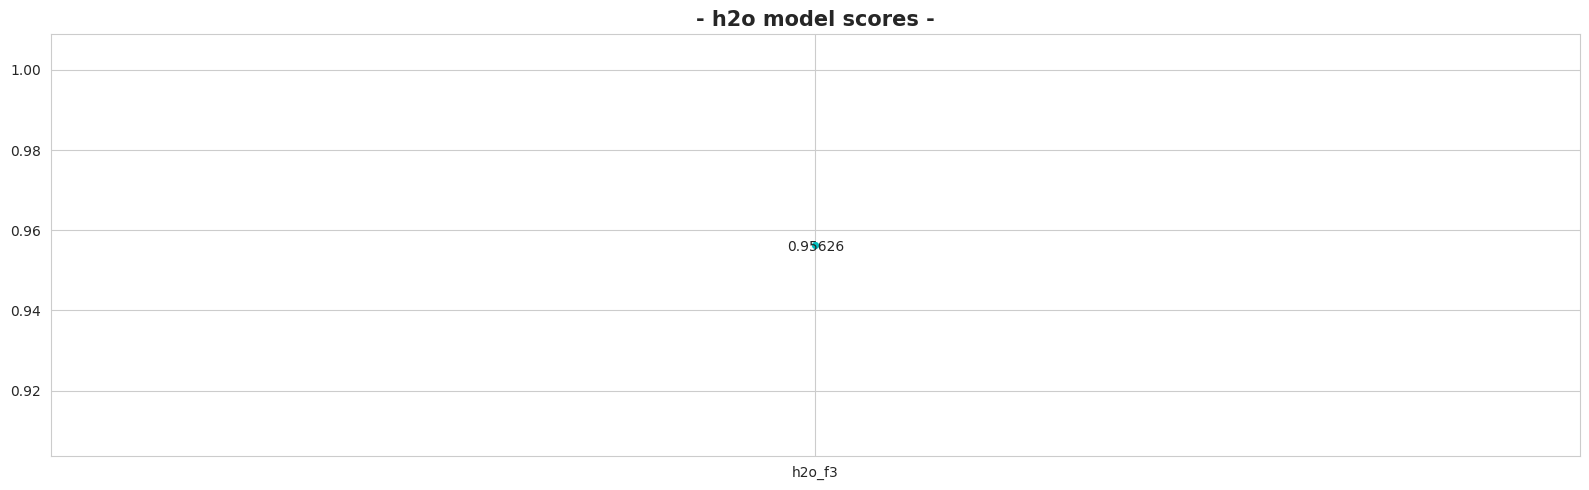

In [38]:
## -- Get Scores -- 
all_model_scores = {}
all_scores = []

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == "score":
            all_model_scores[k] = y
            all_scores.append(float(y))

print(all_model_scores)

plt.figure(figsize=(16, 5))
sns.lineplot(all_model_scores, marker="o")
plt.title("- h2o model scores -", fontsize=15, fontweight="semibold")
plt.tick_params("x", rotation=0)

for i, s in enumerate(all_model_scores.values()):
    plt.text(float(i), s+1e-5, s, ha="center", va="center_baseline")

plt.tight_layout()
plt.show()

Model: h2o_f3_glm oof/test files saved!


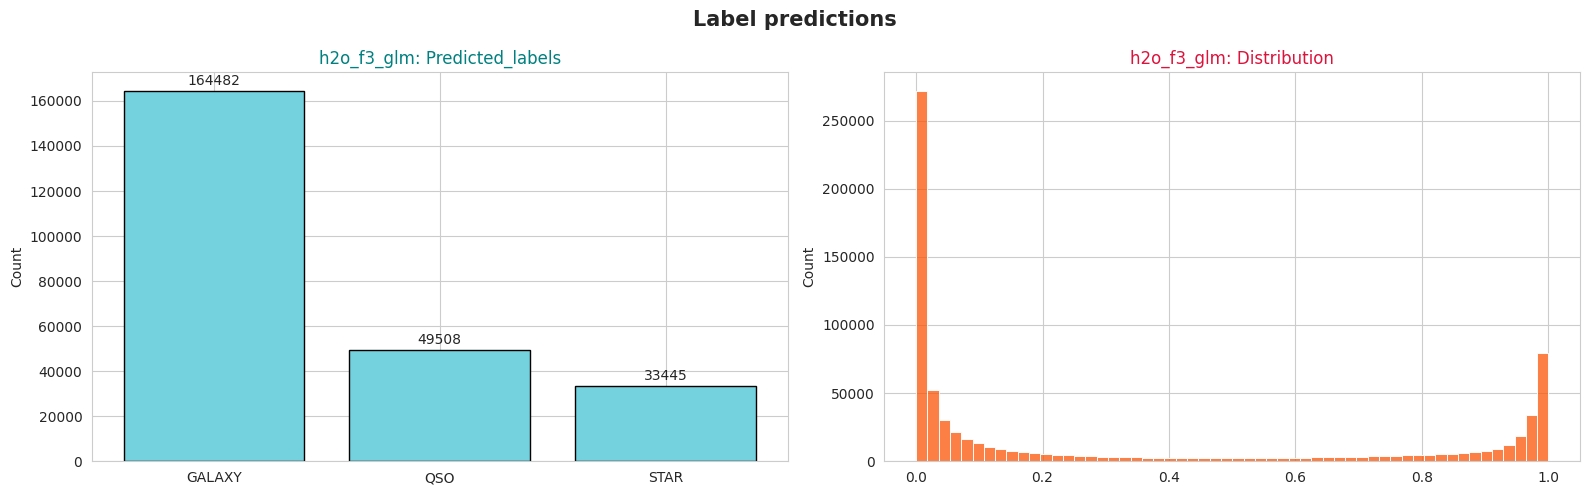


Model: h2o_f3_gbm oof/test files saved!


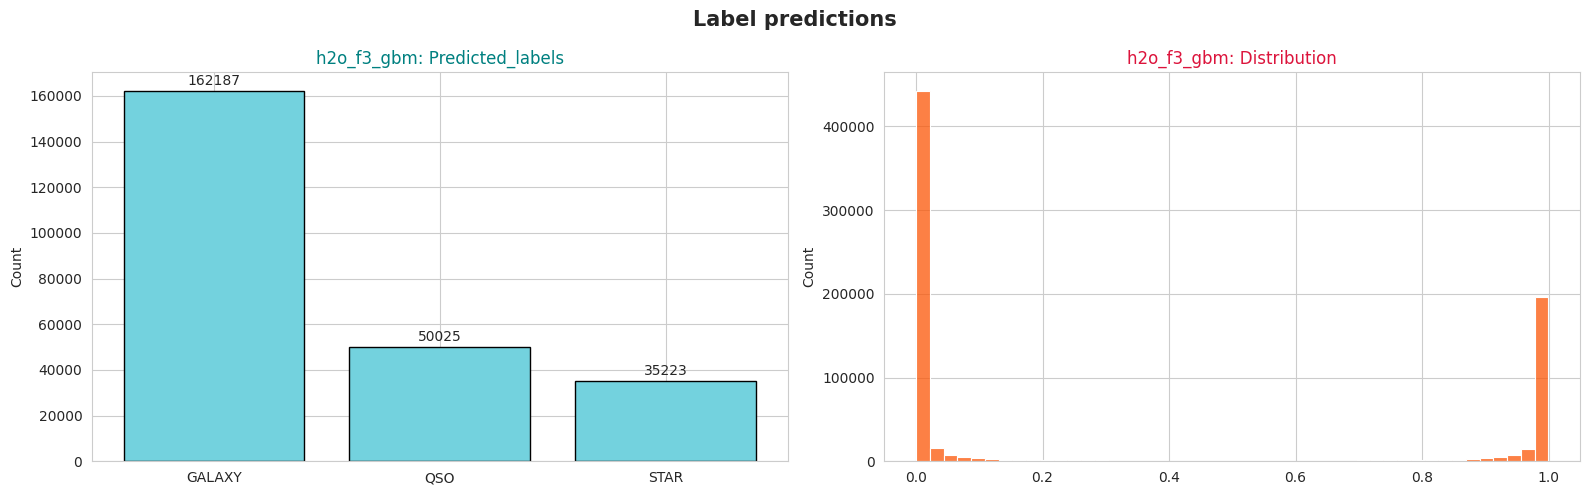


Model: h2o_f3_drf oof/test files saved!


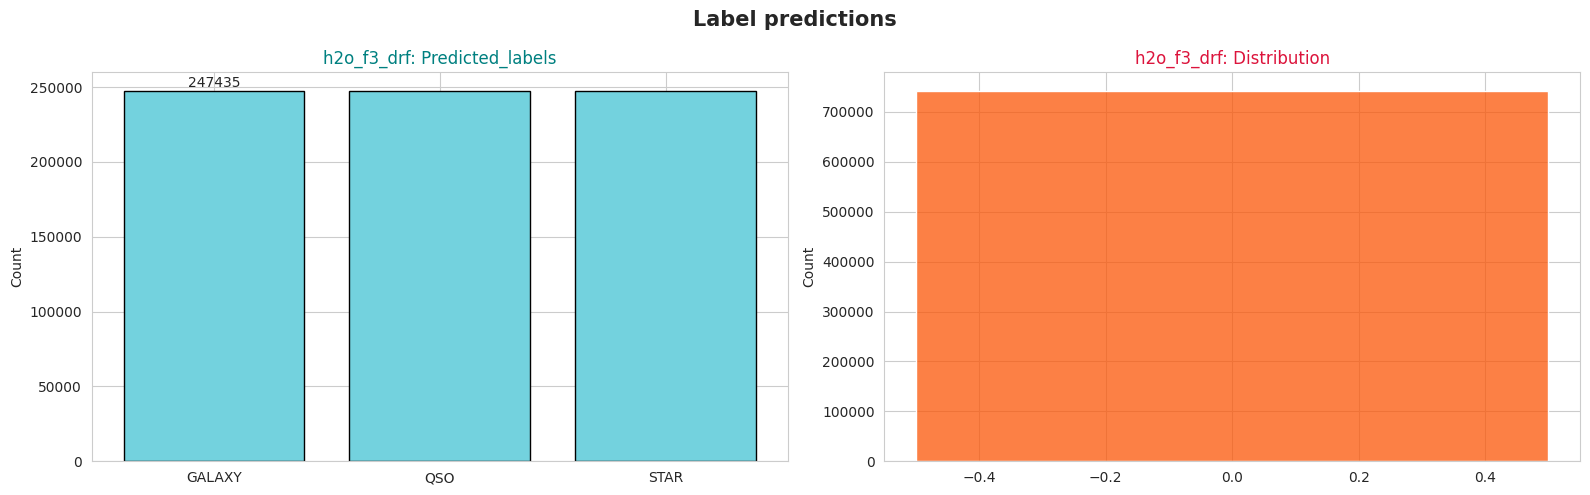


Model: h2o_f3_xgboost oof/test files saved!


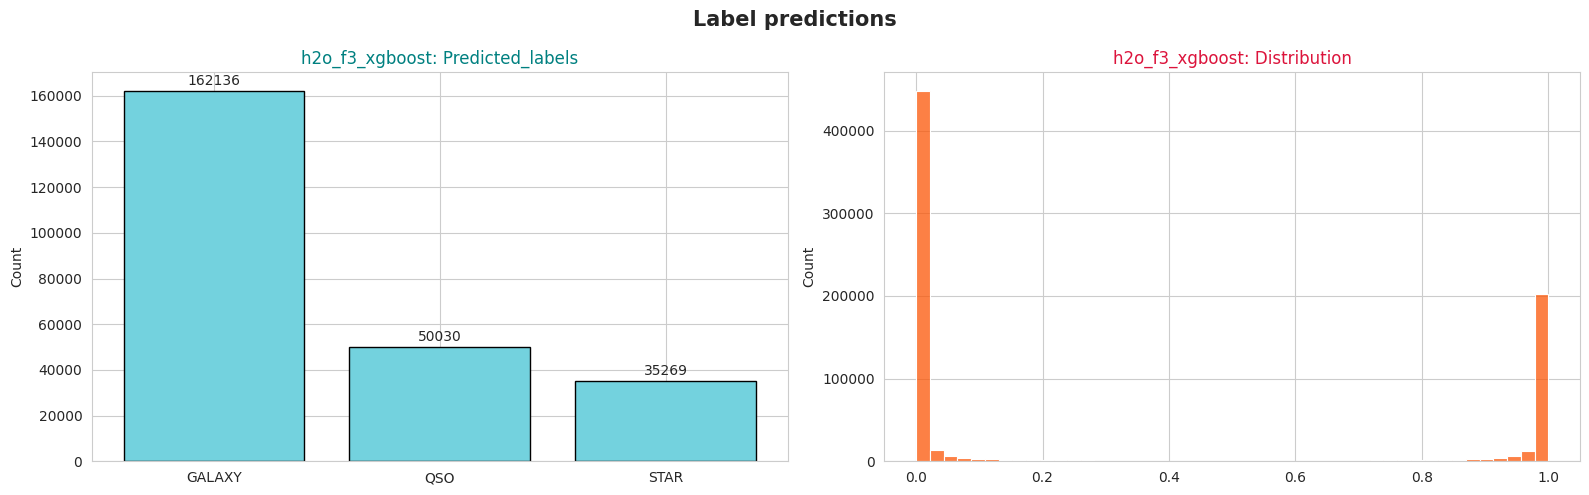


Model: h2o_f3_deeplearning oof/test files saved!


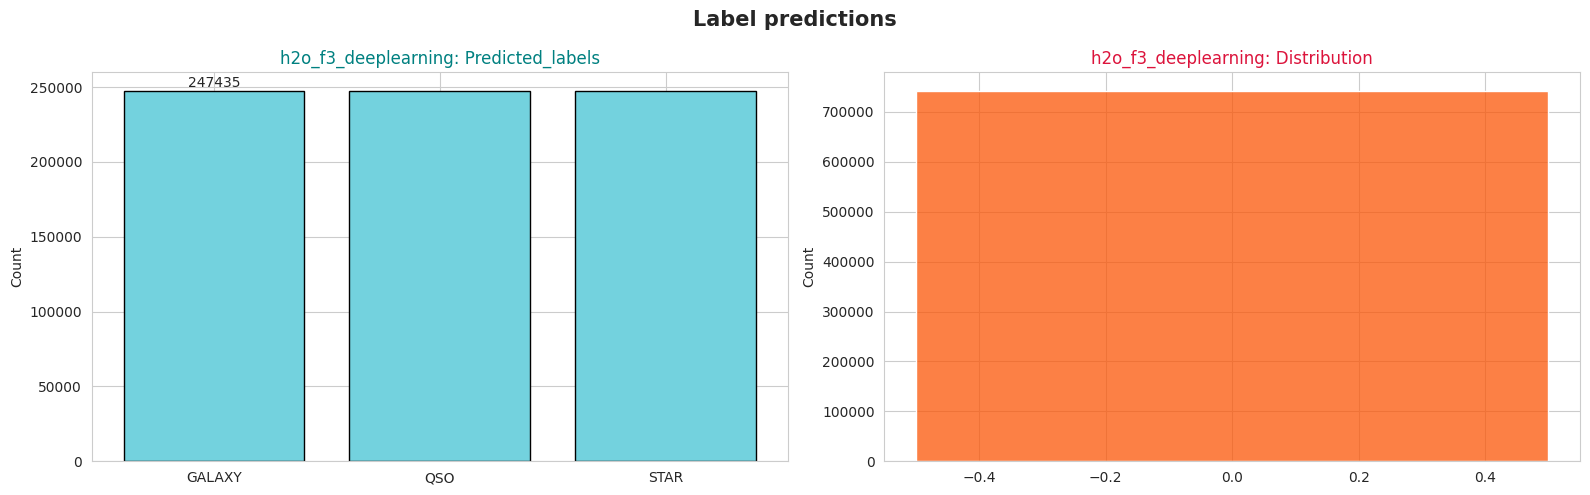

In [39]:
## -- Best of each algorithm group: OOF / TEST predictions:  --
for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == "h2o":
            for (mod, oof_, test_) in y:
                ## -- Save oof predictions --
                n = f"{VERS}_{mod}"
                np.save(f"oof_{n}_.npy", oof_)
                np.save(f"test_{n}_.npy", test_)
                print(f"Model: {CFG['YELLOW']}{n} {CFG['RESET']}oof/test files saved!")
                # ----------------------------------------------------------------------
                preds_ = np.argmax(test_, axis=1)
                counts = [np.sum(preds_ == _) for _ in range(len(np.unique(preds_)))]

                fig, axs = plt.subplots(1, 2, figsize=(16, 5))
                axs[0].bar([*mapping.keys()], counts, color="#73D2DE", edgecolor="k")
                axs[0].set_title(f"{n}: Predicted_labels", color="teal")
                axs[0].set_ylabel("Count")
            
                for i, c in enumerate(counts):
                    axs[0].text(i, c+2500, str(c), ha="center", fontsize=10)
            
                sns.histplot(test_.ravel(), ax=axs[1], color="#FB5607")
                axs[1].set_title(f"{n}: Distribution", color="crimson")
            
                plt.suptitle("Label predictions", fontsize=15, fontweight="semibold")
                plt.tight_layout()
                plt.show()

                print()

oof file h2o_f3_best_95626 saved! * test/submit file h2o_f3_best_95626 saved!

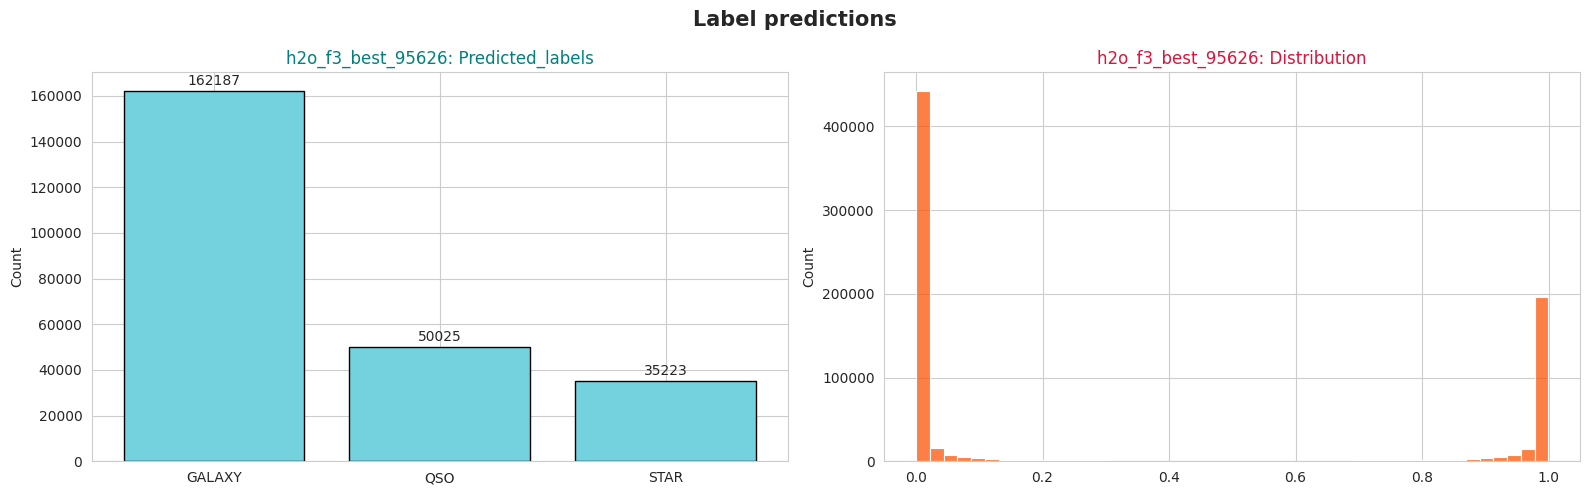

In [40]:
## -- Save BEST MODEL predictions --
for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        ## -- Save TEST predictions --
        if x == "oof_preds":
            n = f"{k}_best_{str(all_scores[i]).split('.')[1]}"
            np.save(f"oof_{n}_.npy", y)
            print(f"oof file {CFG['YELLOW']}{n}{CFG['RESET']} saved! * ", end="")
        # ----------------------------------------------------------------------
        ## -- Save TEST predictions --
        elif x == "test_preds":
            np.save(f"test_{n}_.npy", y)

            preds_ = np.argmax(y, axis=1)
            submit[TARGET] = pd.Series(preds_).map(r_mapping)
            submit.to_csv(f"submit_{n}.csv", index=False)
            print(f"test/submit file {CFG['YELLOW']}{n}{CFG['RESET']} saved!", end="")

            counts = [np.sum(preds_ == _) for _ in range(len(np.unique(preds_)))]
        
            fig, axs = plt.subplots(1, 2, figsize=(16, 5))
            axs[0].bar([*mapping.keys()], counts, color="#73D2DE", edgecolor="k")
            axs[0].set_title(f"{n}: Predicted_labels", color="teal")
            axs[0].set_ylabel("Count")
        
            for i, c in enumerate(counts):
                axs[0].text(i, c+2500, str(c), ha="center", fontsize=10)

            sns.histplot(y.ravel(), ax=axs[1], color="#FB5607")
            axs[1].set_title(f"{n}: Distribution", color="crimson")
        
            plt.suptitle("Label predictions", fontsize=15, fontweight="semibold")
            plt.tight_layout()
            plt.show()

            print()

# XAI

In [41]:
# ## -- Inspect model -- 
# get_model = all_predictions[list(all_predictions.keys())[0]]

# get_model["model"].explain(
#     get_model["val_data"],
#     exclude_explanations=["shap_summary"],
#     top_n_features=3,
#     figsize=(18, 10),
# )

## --- OR ----- ##

# h2o.explain(get_model['model'], get_model['val_data'], top_n_features=3,
#             figsize=(18, 8), exclude_explanations=['shap_summary'])

# HILLCLIMB

In [42]:
# try:
#     from hillclimbers import climb_hill, partial
# except:
#     %pip install -q -U hillclimbers
#     from hillclimbers import climb_hill, partial

In [43]:
def dataloader(filepath, train_prefix, test_prefix):    
    # Store dataframes in lists
    train_list = []
    test_list  = []

    print('Loading .npy files: ')
    for (root, dirs, files) in os.walk(filepath):
        # Filter files first to ensure accurate tqdm count
        npy_files = [f for f in sorted(files) if f.endswith('.npy')]
        
        for file in tqdm(npy_files):
            arr = np.load(os.path.join(root, file))
            base_name = file.replace('.npy', '')
            
            # Create the 3-column chunk
            new_cols = pd.DataFrame(
                arr, 
                columns=[f"{base_name}_c{c}" for c in range(3)]
            )
            
            if train_prefix in file:
                train_list.append(new_cols)
            elif test_prefix in file:
                test_list.append(new_cols)
    
    # Concatenate everything at once
    train_df = pd.concat(train_list, axis=1) if train_list else pd.DataFrame()
    test_df  = pd.concat(test_list, axis=1) if test_list else pd.DataFrame()

    train_df.columns = [c.replace('oof_', '') for c in train_df.columns]
    test_df.columns  = [c.replace('test_', '') for c in test_df.columns]
    
    return train_df, test_df, train_list

def rename_duplicate_cols(df: pd.DataFrame) -> pd.DataFrame:
    original_cols = list(df.columns)
    new_cols = []
    # Track how many times we've seen each original name
    seen = {}

    for col in tqdm(original_cols, desc="Fixing columns"):
        if col not in seen:
            # First occurrence: keep name unchanged
            seen[col] = 1
            new_cols.append(col)
        else:
            # Duplicate: append suffix _k where k starts at 0
            suffix = seen[col] - 1 # 0 for first duplicate, 1 for second,
            new_name = f"{col}_{suffix}"
            new_cols.append(new_name)
            seen[col] += 1

    # Apply new column names
    df_renamed = df.copy()
    df_renamed.columns = new_cols

    return df_renamed
    
print('Data loader function ready!')

Data loader function ready!


In [44]:
# OOF_PATH = "/kaggle/working/"
# oof_df, test_df, col_names = dataloader(OOF_PATH, "oof", "test")

# per_model_class_output = []
# desc = 'Extracting class names'

# for model in tqdm(col_names, total=len(col_names), desc=desc):
#     model.columns = [c.replace("oof_", "") for c in model.columns]
#     per_model_class_output.append(model.columns.tolist())

# ## -- Drop models if necessary --
# for c in oof_df.columns:
#     if "best" in c: #
#         oof_df.drop(columns=[c],  inplace=True)
#         test_df.drop(columns=[c], inplace=True)

# print("-"*50)
# ## -- Check for missingness --
# print(f"OOF  Null: {oof_df.isna().sum().sum()} | ",end="")
# print(f"TEST Null: {test_df.isna().sum().sum()}")
# print("-"*50)

# ## -- Apply column rename function --
# oof_df  = rename_duplicate_cols(oof_df)
# test_df = rename_duplicate_cols(test_df)

# print()
# print(f"{CFG['YELLOW']} • Columns updated: {oof_df.shape[1]}")

# display(oof_df.head(3))
# print()
# display(test_df.head(3))

In [45]:
# %%time

# trn = pd.read_csv(PATH+"train.csv").drop(columns=['id'])
# pred_hc, oof_hc = climb_hill(
#                                train = train_data,
#                               target = TARGET,
#                          oof_pred_df = oof_df,
#                         test_pred_df = test_df,
#                            objective = "maximize",
#                          eval_metric = partial(roc_auc_score),
#                     # negative_weights = True,
#                     return_oof_preds = True,
#                            precision = 0.01,
#                            plot_hill = True,
#                            plot_hist = True,
# )

In [46]:
# hc_score = str(round(roc_auc_score(train_data[TARGET], oof_hc), 5)).split('.')[1]
# print(f"Hillclimb score: {hc_score}")

# np.save(f"oof_{VERS}_hillclimb_{hc_score}_.npy", oof_hc)
# np.save(f"test_{VERS}_hillclimb_{hc_score}_.npy", pred_hc)

# submit[TARGET] = pred_hc
# submit.to_csv(f"submit_{VERS}_hillclimb_{hc_score}.csv", index=False)
# print(f"\n✅ Saved hillclimb ensemble!")

# submit.head(10)